In [25]:
import matplotlib.pyplot as plt

In [22]:
from collections import defaultdict
import os

def group_images_by_ending_number(folder_path):

    grouped_images = defaultdict(list)
    

    for filename in os.listdir(folder_path):
        if filename.endswith(".tif"):
            name_without_ext = filename.split(".")[0]
            parts = name_without_ext.split("_")
            ending_number = parts[-1]
            
            middle_number = int(parts[2]) 
            full_path = os.path.join(folder_path, filename)
            
            grouped_images[ending_number].append((middle_number, full_path))
            
    for ending_number in grouped_images:
        grouped_images[ending_number].sort(key=lambda x: x[0])
        grouped_images[ending_number] = [filename for _, filename in grouped_images[ending_number]]
    
    return grouped_images


folder_path = "/root/home/data"
grouped_images = group_images_by_ending_number(folder_path)


for ending_number, files in grouped_images.items():
    print(ending_number,files)

430 ['/root/home/data/pos_rgb_0_tile_430.tif', '/root/home/data/pos_rgb_1_tile_430.tif', '/root/home/data/pos_rgb_2_tile_430.tif', '/root/home/data/pos_rgb_3_tile_430.tif', '/root/home/data/pos_rgb_4_tile_430.tif', '/root/home/data/pos_rgb_5_tile_430.tif']
509 ['/root/home/data/neg_rgb_0_tile_509.tif', '/root/home/data/neg_rgb_1_tile_509.tif', '/root/home/data/neg_rgb_2_tile_509.tif', '/root/home/data/neg_rgb_3_tile_509.tif', '/root/home/data/neg_rgb_4_tile_509.tif', '/root/home/data/neg_rgb_5_tile_509.tif']
972 ['/root/home/data/pos_rgb_0_tile_972.tif', '/root/home/data/pos_rgb_1_tile_972.tif', '/root/home/data/pos_rgb_2_tile_972.tif', '/root/home/data/pos_rgb_3_tile_972.tif', '/root/home/data/pos_rgb_4_tile_972.tif', '/root/home/data/pos_rgb_5_tile_972.tif']
832 ['/root/home/data/neg_rgb_0_tile_832.tif', '/root/home/data/neg_rgb_1_tile_832.tif', '/root/home/data/neg_rgb_2_tile_832.tif', '/root/home/data/neg_rgb_3_tile_832.tif', '/root/home/data/neg_rgb_4_tile_832.tif', '/root/home/da

In [23]:
def create_collage(images, grid_rows, grid_cols, padding=10):

    img = Image.open(images[0])
    img_width, img_height = img.size

    collage_width = grid_cols * img_width + (grid_cols + 1) * padding
    collage_height = grid_rows * img_height + (grid_rows + 1) * padding

    collage = Image.new('RGB', (collage_width, collage_height), 'white')

    for i, img_path in enumerate(images):
        img = Image.open(img_path).resize((img_width, img_height), Image.ANTIALIAS)
        x = (i % grid_cols) * (img_width + padding) + padding
        y = (i // grid_cols) * (img_height + padding) + padding
        collage.paste(img, (x,y))

    return collage

In [48]:
folder_to_save='/home/pupil/rmf3mc/Downloads/JobBasedOnGPT/CVPRJobs/collage'

for key in grouped_images:
    print(key)
    collage=create_collage(grouped_images[key], 2, 3, padding=10)
    image_new_path=os.path.join(folder_to_save,f"{grouped_images[key][0].split('_')[0][-3:]}_collage_{key}.jpg")
    collage.save(image_new_path, "JPEG")
    os.chmod(image_new_path, 0o666)
    user_id = 569  # Replace with the target user's UID
    group_id = 501  # Replace with the target group's GID
    os.chown(image_new_path, user_id, group_id)

430
509
972
832
107
1150
490
14
760
945
549
131
1123
539
1047
629
297
753
999
545
501
192
193
358
1096
377
485
512
86
417
28
746
853
1065
415


/tmp/ipykernel_61/817156529.py:17: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  img = Image.open(img_path).resize((img_width, img_height), Image.ANTIALIAS)


984
530
266
991
29
361
339
440
879
608
949
1
59
259
929
943
851
529
391
834
267
664
777
725
1045
486
1046
115
1073
697
176
101
292
331
649
231
1070
468
1036
552
182
934
921
1019
950
55
1084
384
327
283
685
106
31
1005
207
303
172
741
822
801
885
349
663
273
644
63
505
95
816
100
197
860
522
525
19
470
155
484
688
260
944
181
584
249
286
219
234
578
409
1145
809
244
261
719
252
1134
587
626
774
299
194
171
847
199
88
335
1030
848
328
382
491
810
710
543
829
64
431
965
472
1142
546
393
904
77
345
682
839
1014
433
646
302
196
596
165
473
93
443
742
175
383
53
315
464
210
38
1147
878
320
913
818
1092
662
380
373
6
457
227
346
134
425
887
45
190
962
242
287
1006
764
1128
896
748
70
555
154
362
947
583
679
808
902
597
105
855
1146
925
411
849
557
471
189
158
301
661
607
104
1080
293
1133
397
993
880
870
826
163
975
863
803
394
856
326
16
102
915
1017
755
1021
973
712
162
224
1020
453
1085
723
614
779
204
1063
203
444
821
322
319
740
61
1121
861
458
428
1058
145
251
854
687
1111
765
476
233
7

IndexError: list index out of range

In [38]:
def display_image(img):
    plt.figure(figsize=(20, 20))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

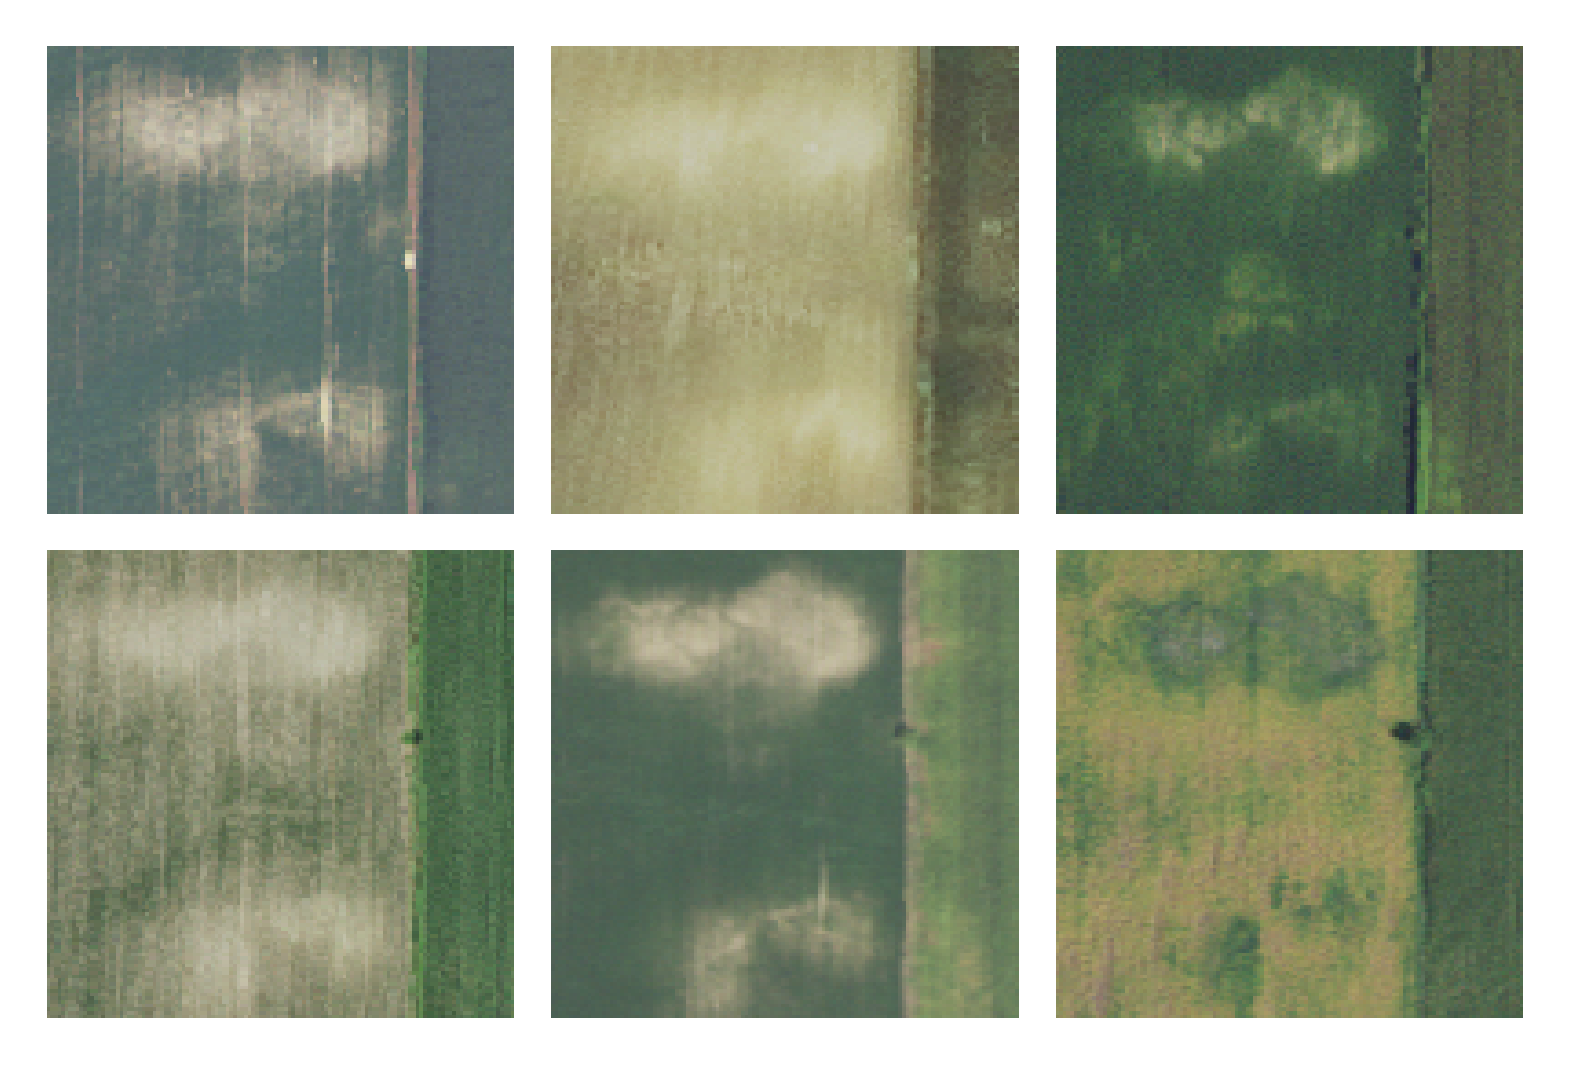

In [49]:
display_image(collage)

In [51]:
collage.size

(424, 286)